Intento de request

In [47]:
import pandas as pd
import os
import json
from dotenv import load_dotenv
import requests
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import calendar 

In [2]:
# Carga las variables del archivo .env en el entorno del sistema
# Si el archivo .env está en la misma carpeta que este notebook, basta con esto:
# Al usar '../.env', le decimos que salga de 'sandbox' y busque el archivo en la raíz
load_dotenv()
# Si tu .env está en una carpeta superior o una ruta específica, puedes indicarla:
# load_dotenv(dotenv_path="../.env")

# Recuperamos el token de forma segura
TOKEN = os.getenv("API_ESIOS")

# Verificación rápida (sin mostrar el token entero por seguridad)
if TOKEN:
    print(f"✅ Token cargado correctamente. Longitud: {len(TOKEN)} caracteres.")
else:
    print("❌ No se pudo encontrar la variable ESIOS_TOKEN. Revisa la ruta del archivo .env.")

✅ Token cargado correctamente. Longitud: 64 caracteres.


In [3]:
# 1. Configuración de la petición
TOKEN_ESIOS = TOKEN  # Reemplaza con tu token
INICIO = "2026-06-28T00:00:00"
FIN = "2026-06-28T23:59:59"

HEADERS = {
    'x-api-key': TOKEN_ESIOS,
    'Accept': 'application/json; application/vnd.esios-api-v2+json',
    'Content-Type': 'application/json'
}

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}

def traer_dataframe_indicador(indicador_id):
    """Hace la petición a e·sios con x-api-key v2 y devuelve un DataFrame limpio"""
    url = f"https://api.esios.ree.es/indicators/{indicador_id}"
    response = requests.get(url, headers=HEADERS, params=PARAMS)
    response.raise_for_status()
    
    # Extraemos la lista de valores del JSON
    datos_json = response.json()['indicator']['values']
    
    # Convertimos a DataFrame
    df = pd.DataFrame(datos_json)
    
    # Verificación de la columna de tiempo por si la API la nombra 'datetime_utc'
    columna_fecha = 'datetime' if 'datetime' in df.columns else 'datetime_utc'
    
    # Normalización del DataFrame para el merge
    df[columna_fecha] = pd.to_datetime(df[columna_fecha], utc=True)
    df = df[[columna_fecha, 'value']].rename(
        columns={columna_fecha: 'datetime', 'value': f'indicador_{indicador_id}'}
    )
    
    return df

# 2. Extracción con los IDs correctos del set del proyecto
# 1293: Demanda Real Peninsular
# 544: Previsión de la Demanda de REE
try:
    df_real = traer_dataframe_indicador(1293)
    df_prevista = traer_dataframe_indicador(544)
    
    # 3. Combinación para el análisis de desviaciones / anomalías
    df_demanda = pd.merge(df_real, df_prevista, on='datetime', how='inner')
    df_demanda = df_demanda.rename(columns={
        'indicador_1293': 'Demanda_Real_MW',
        'indicador_544': 'Demanda_Prevista_MW'
    })
    
    # Mostramos los primeros datos en el Notebook
    display(df_demanda.head())

except requests.exceptions.HTTPError as e:
    print(f"Error de la API (403/404): {e}")
except KeyError as e:
    print(f"Error en la estructura de columnas del JSON: {e}")

,datetime,Demanda_Real_MW,Demanda_Prevista_MW
0,2026-06-27 22:00:00+00:00,28093.0,27937.0
1,2026-06-27 22:05:00+00:00,28173.0,27801.0
2,2026-06-27 22:10:00+00:00,28279.0,27652.0
3,2026-06-27 22:15:00+00:00,28099.0,27490.0
4,2026-06-27 22:20:00+00:00,27807.0,27325.0


In [4]:
def listar_todos_los_indicadores():
    """Trae el catálogo completo de indicadores disponibles en e·sios"""
    url = "https://api.esios.ree.es/indicators"
    
    response = requests.get(url, headers=HEADERS)
    response.raise_for_status()
    
    # La respuesta envuelve todo en una lista bajo la clave 'indicators'
    indicadores_json = response.json()['indicators']
    
    # Convertimos a DataFrame para que sea legible y fácil de filtrar
    df_indicators = pd.DataFrame(indicadores_json)
    
    # Seleccionamos las columnas más útiles para trabajar
    columnas_interes = ['id', 'name', 'short_name', 'description']
    # Nos aseguramos de coger solo las que existan en la respuesta por si cambia el esquema
    columnas_validas = [col for col in columnas_interes if col in df_indicators.columns]
    
    return df_indicators[columnas_validas]

try:
    # 1. Obtener el catálogo completo
    df_catalogo = listar_todos_los_indicadores()
    print(f"Catálogo cargado con éxito. Total de indicadores encontrados: {len(df_catalogo)}")
    
    # 2. Ejemplo de búsqueda interactiva en el Notebook:
    # Busquemos indicadores que contengan la palabra "demanda" (ignorando mayúsculas)
    busqueda = df_catalogo[df_catalogo['name'].str.contains('demanda', case=False, na=False)]
    
    # Mostramos los primeros resultados del filtro
    display(busqueda[['id', 'name']].head(20))

except requests.exceptions.HTTPError as e:
    print(f"Error al consultar el catálogo: {e}")

Catálogo cargado con éxito. Total de indicadores encontrados: 1969


,id,name
350,351,Demanda programada PBF Comercializadores merca...
351,352,Demanda programada PBF Comercializadores de re...
352,353,Demanda programada PBF Consumos directos en me...
353,354,Demanda programada PBF Consumo de Servicios Au...
354,355,Demanda programada PBF Corrección eólica
355,356,Demanda programada PBF Corrección solar
356,357,Demanda programada PBF Corrección REE
357,358,Demanda programada PVP Comercializadores merca...
358,359,Demanda programada PVP Comercializadores de re...
359,360,Demanda programada PVP Consumos directos en me...


Resample a 1 hora, y cálculo del residuo

In [5]:
# 1. Pasar 'datetime' a índice, remuestrear a horario con la media y calcular el residuo
df_horario = (
    df_demanda.set_index('datetime')
    .resample('1h')
    .mean()
)

# 2. Calcular el residuo (Demanda Real - Demanda Prevista)
df_horario['Residuo_MW'] = df_horario['Demanda_Real_MW'] - df_horario['Demanda_Prevista_MW']

# 3. Control visual (esperamos ~24 filas y las 3 columnas calculadas)
display(df_horario.head(5))

,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW
datetime,,,
2026-06-27 22:00:00+00:00,27555.416667,27107.666667,447.750000
2026-06-27 23:00:00+00:00,25938.666667,25535.166667,403.500000
2026-06-28 00:00:00+00:00,24687.666667,24511.333333,176.333333
2026-06-28 01:00:00+00:00,23632.666667,23669.000000,-36.333333
2026-06-28 02:00:00+00:00,23028.000000,23238.000000,-210.000000


In [6]:
df_horario["Residuo_MW"].describe()

count     24.000000
mean      38.409722
std      426.307502
min     -793.583333
25%     -232.979167
50%       88.708333
75%      364.604167
max      857.666667
Name: Residuo_MW, dtype: float64

Análisis de 30 días

In [7]:
INICIO = "2026-05-28T00:00:00"
FIN = "2026-06-28T23:59:59"

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}

In [8]:
try:
    df_real = traer_dataframe_indicador(1293)
    df_prevista = traer_dataframe_indicador(544)
    
    # 3. Combinación para el análisis de desviaciones / anomalías
    df_demanda = pd.merge(df_real, df_prevista, on='datetime', how='inner')
    df_demanda = df_demanda.rename(columns={
        'indicador_1293': 'Demanda_Real_MW',
        'indicador_544': 'Demanda_Prevista_MW'
    })
    
    # Mostramos los primeros datos en el Notebook
    display(df_demanda)

except requests.exceptions.HTTPError as e:
    print(f"Error de la API (403/404): {e}")
except KeyError as e:
    print(f"Error en la estructura de columnas del JSON: {e}")

,datetime,Demanda_Real_MW,Demanda_Prevista_MW
0,2026-05-27 22:00:00+00:00,26681.0,27269.0
1,2026-05-27 22:05:00+00:00,26818.0,27140.0
2,2026-05-27 22:10:00+00:00,27097.0,27000.0
3,2026-05-27 22:15:00+00:00,26978.0,26850.0
4,2026-05-27 22:20:00+00:00,26784.0,26697.0
...,...,...,...
9211,2026-06-28 21:35:00+00:00,28951.0,28689.0
9212,2026-06-28 21:40:00+00:00,28244.0,28483.0
9213,2026-06-28 21:45:00+00:00,28182.0,28226.0
9214,2026-06-28 21:50:00+00:00,28389.0,28054.0


In [9]:
# 1. Pasar 'datetime' a índice, remuestrear a horario con la media y calcular el residuo
df_horario = (
    df_demanda.set_index('datetime')
    .resample('1h')
    .mean()
)

# 2. Calcular el residuo (Demanda Real - Demanda Prevista)
df_horario['Residuo_MW'] = df_horario['Demanda_Real_MW'] - df_horario['Demanda_Prevista_MW']

# 3. Control visual (esperamos ~24 filas y las 3 columnas calculadas)
display(df_horario)

,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW
datetime,,,
2026-05-27 22:00:00+00:00,26463.833333,26488.250000,-24.416667
2026-05-27 23:00:00+00:00,24921.666667,24889.250000,32.416667
2026-05-28 00:00:00+00:00,23761.333333,23938.500000,-177.166667
2026-05-28 01:00:00+00:00,23416.416667,23442.166667,-25.750000
2026-05-28 02:00:00+00:00,23169.833333,23097.333333,72.500000
...,...,...,...
2026-06-28 17:00:00+00:00,32140.833333,32934.416667,-793.583333
2026-06-28 18:00:00+00:00,31333.916667,31871.166667,-537.250000
2026-06-28 19:00:00+00:00,30434.666667,31187.083333,-752.416667


In [10]:
df_horario.groupby(df_horario.index.hour)["Residuo_MW"].agg(["mean", "std"])

,mean,std
datetime,,
0,29.515625,251.322670
1,34.533854,176.342377
2,-15.497396,164.510688
3,-8.966146,171.643631
4,-18.187500,187.147333
5,-49.752604,275.375714
6,-127.572917,348.851578
7,-6.346354,505.710499
8,48.989583,413.860041


Feature: day of the week

In [11]:
# 1. Filtrar solo los días laborables (Lunes=0 a Viernes=4)
df_laborables = df_horario[df_horario.index.dayofweek < 5]

df_laborables

,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW
datetime,,,
2026-05-27 22:00:00+00:00,26463.833333,26488.250000,-24.416667
2026-05-27 23:00:00+00:00,24921.666667,24889.250000,32.416667
2026-05-28 00:00:00+00:00,23761.333333,23938.500000,-177.166667
2026-05-28 01:00:00+00:00,23416.416667,23442.166667,-25.750000
2026-05-28 02:00:00+00:00,23169.833333,23097.333333,72.500000
...,...,...,...
2026-06-26 19:00:00+00:00,34885.916667,34810.833333,75.083333
2026-06-26 20:00:00+00:00,33118.083333,33442.166667,-324.083333
2026-06-26 21:00:00+00:00,31043.750000,31333.666667,-289.916667


In [12]:
# 2. Agrupar por hora y calcular la media (o la métrica que necesites)
df_por_hora = df_laborables.groupby(df_laborables.index.hour)["Residuo_MW"].agg(["mean", "std"])
print(df_por_hora)

                mean          std
datetime                         
0          25.613636   282.109627
1          31.393939   193.342710
2          -8.609848   153.377526
3         -17.098485   148.020141
4         -47.500000   199.282597
5         -66.962121   307.462906
6        -197.121212   298.454995
7        -131.371212   538.732575
8         -22.878788   438.167866
9         149.613636   253.389858
10        177.007576   314.003551
11         85.625000   370.367040
12        -46.151515   198.910511
13         43.859848   316.815673
14        -62.291667   405.727669
15       -247.193182   671.337175
16       -381.030303  1311.157113
17       -425.534091  1700.959230
18       -288.924242  1814.711371
19        189.117424   339.409626
20        131.030303   413.812510
21         46.473485   327.278991
22         24.206522   262.713737
23         51.804348   287.706999


In [13]:
#fines  de semana
df_finde = df_horario[df_horario.index.dayofweek >= 5]
df_finde.groupby(df_finde.index.hour)["Residuo_MW"].agg(["mean", "std"])

,mean,std
datetime,,
0,38.100000,178.163803
1,41.441667,140.748830
2,-30.650000,194.827309
3,8.925000,223.244390
4,46.300000,145.782924
5,-11.891667,195.713198
6,25.433333,416.535273
7,268.708333,285.328328
8,207.100000,318.721587


La celda de referencia para el z-score no puede ser solo hora; tiene que ser (tipo_día, hora)

In [14]:
df_horario["tipo_dia"] = np.where(df_horario.index.dayofweek < 5, "laborable", "finde")
tabla_ref = df_horario.groupby(["tipo_dia", df_horario.index.hour])["Residuo_MW"].agg(["mean", "std"])
tabla_ref

mean          std
tipo_dia  datetime                         
finde     0          38.100000   178.163803
          1          41.441667   140.748830
          2         -30.650000   194.827309
          3           8.925000   223.244390
          4          46.300000   145.782924
          5         -11.891667   195.713198
          6          25.433333   416.535273
          7         268.708333   285.328328
          8         207.100000   318.721587
          9         153.441667   439.615905
          10        125.941667   349.873494
          11         83.375000   324.038640
          12        114.883333   259.408611
          13         65.333333   275.117506
          14         24.816667   280.750270
          15         71.633333   309.780306
          16         91.400000   470.134356
          17        -25.250000   602.030369
          18        -53.600000   318.979599
          19        -85.925000   344.672750
          20        -60.250000   328.364748
          21        119.141667   247.177187
          22         -8.611111   221.599857
          23        -36.194444   238.507243
laborable 0          25.613636   282.109627
          1          31.393939   193.342710
          2          -8.609848   153.377526
          3         -17.098485   148.020141
          4         -47.500000   199.282597
          5         -66.962121   307.462906
          6        -197.121212   298.454995
          7        -131.371212   538.732575
          8         -22.878788   438.167866
          9         149.613636   253.389858
          10        177.007576   314.003551
          11         85.625000   370.367040
          12        -46.151515   198.910511
          13         43.859848   316.815673
          14        -62.291667   405.727669
          15       -247.193182   671.337175
          16       -381.030303  1311.157113
          17       -425.534091  1700.959230
          18       -288.924242  1814.711371
          19        189.117424   339.409626
          20        131.030303   413.812510
          21         46.473485   327.278991
          22         24.206522   262.713737
          23         51.804348   287.706999

In [15]:
# Z score

In [16]:
tabla_ref = df_horario.groupby(["tipo_dia", df_horario.index.hour])["Residuo_MW"].agg(["mean", "std"])
tabla_ref = tabla_ref.reset_index().rename(columns={"datetime": "hora"})

df_horario["fecha_hora"] = df_horario.index
df_horario["hora"] = df_horario.index.hour
df_horario["tipo_dia"] = np.where(df_horario.index.dayofweek < 5, "laborable", "finde")

df_horario = df_horario.merge(tabla_ref, on=["tipo_dia", "hora"], how="left")
df_horario["z_score"] = (df_horario["Residuo_MW"] - df_horario["mean"]) / df_horario["std"]

In [17]:
df_horario

,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW,tipo_dia,fecha_hora,hora,mean,std,z_score
0,26463.833333,26488.250000,-24.416667,laborable,2026-05-27 22:00:00+00:00,22,24.206522,262.713737,-0.185080
1,24921.666667,24889.250000,32.416667,laborable,2026-05-27 23:00:00+00:00,23,51.804348,287.706999,-0.067387
2,23761.333333,23938.500000,-177.166667,laborable,2026-05-28 00:00:00+00:00,0,25.613636,282.109627,-0.718800
3,23416.416667,23442.166667,-25.750000,laborable,2026-05-28 01:00:00+00:00,1,31.393939,193.342710,-0.295558
4,23169.833333,23097.333333,72.500000,laborable,2026-05-28 02:00:00+00:00,2,-8.609848,153.377526,0.528825
...,...,...,...,...,...,...,...,...,...
763,32140.833333,32934.416667,-793.583333,finde,2026-06-28 17:00:00+00:00,17,-25.250000,602.030369,-1.276237
764,31333.916667,31871.166667,-537.250000,finde,2026-06-28 18:00:00+00:00,18,-53.600000,318.979599,-1.516241
765,30434.666667,31187.083333,-752.416667,finde,2026-06-28 19:00:00+00:00,19,-85.925000,344.672750,-1.933694
766,30444.333333,30966.500000,-522.166667,finde,2026-06-28 20:00:00+00:00,20,-60.250000,328.364748,-1.406718


In [18]:

fig = go.Figure()

for tipo, color in [("laborable", "steelblue"), ("finde", "orange")]:
    subset = df_horario[df_horario["tipo_dia"] == tipo]
    fig.add_trace(go.Scatter(
        x=subset["fecha_hora"], y=subset["z_score"],
        mode="markers", name=tipo,
        marker=dict(size=4, color=color, opacity=0.6)
    ))

# Umbrales de referencia
for nivel in [2, -2, 3, -3]:
    fig.add_hline(y=nivel, line_dash="dot", line_color="red" if abs(nivel)==3 else "gray")

fig.update_layout(title="Z-score del residuo horario (condicional a tipo_día + hora)", xaxis_title="Fecha", yaxis_title="z-score")
fig.show()

In [19]:
df_horario[df_horario["z_score"] < -3][["fecha_hora","Demanda_Real_MW", "Demanda_Prevista_MW", "Residuo_MW", "tipo_dia", "hora", "z_score"]]

,fecha_hora,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW,tipo_dia,hora,z_score
297,2026-06-09 07:00:00+00:00,31537.750000,33349.166667,-1811.416667,laborable,7,-3.118515
353,2026-06-11 15:00:00+00:00,30776.333333,33693.916667,-2917.583333,laborable,15,-3.977718
354,2026-06-11 16:00:00+00:00,28284.416667,34198.750000,-5914.333333,laborable,16,-4.220168
355,2026-06-11 17:00:00+00:00,26732.500000,34566.666667,-7834.166667,laborable,17,-4.355562
356,2026-06-11 18:00:00+00:00,25173.333333,33470.166667,-8296.833333,laborable,18,-4.412773


In [20]:
df_horario[df_horario["z_score"] > 3][["fecha_hora","Demanda_Real_MW", "Demanda_Prevista_MW", "Residuo_MW", "tipo_dia", "hora", "z_score"]]

,fecha_hora,Demanda_Real_MW,Demanda_Prevista_MW,Residuo_MW,tipo_dia,hora,z_score
613,2026-06-22 11:00:00+00:00,40507.083333,39249.666667,1257.416667,laborable,11,3.163866


In [21]:
# ¿El dato crudo de e·sios coincide con lo que tienes en df_horario para esas fechas?
# Vuelve a pedir 1293 directo a la API para 2026-06-11, sin pasar por el pipeline completo

In [22]:
INICIO = "2026-06-11T03:00:00"
FIN = "2026-06-12T02:59:59"

HEADERS = {
    'x-api-key': TOKEN_ESIOS,
    'Accept': 'application/json; application/vnd.esios-api-v2+json',
    'Content-Type': 'application/json'
}

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}

def traer_dataframe_indicador(indicador_id):
    """Hace la petición a e·sios con x-api-key v2 y devuelve un DataFrame limpio"""
    url = f"https://api.esios.ree.es/indicators/{indicador_id}"
    response = requests.get(url, headers=HEADERS, params=PARAMS)
    response.raise_for_status()
    
    # Extraemos la lista de valores del JSON
    datos_json = response.json()['indicator']['values']
    
    # Convertimos a DataFrame
    df = pd.DataFrame(datos_json)
    
    # Verificación de la columna de tiempo por si la API la nombra 'datetime_utc'
    columna_fecha = 'datetime' if 'datetime' in df.columns else 'datetime_utc'
    
    # Normalización del DataFrame para el merge
    df[columna_fecha] = pd.to_datetime(df[columna_fecha], utc=True)
    df = df[[columna_fecha, 'value']].rename(
        columns={columna_fecha: 'datetime', 'value': f'indicador_{indicador_id}'}
    )
    
    return df

# 2. Extracción con los IDs correctos del set del proyecto
# 1293: Demanda Real Peninsular
# 544: Previsión de la Demanda de REE
try:
    df_real = traer_dataframe_indicador(1293)
    df_prevista = traer_dataframe_indicador(544)
    
    # 3. Combinación para el análisis de desviaciones / anomalías
    df_demanda_dia = pd.merge(df_real, df_prevista, on='datetime', how='inner')
    df_demanda_dia = df_demanda_dia.rename(columns={
        'indicador_1293': 'Demanda_Real_MW',
        'indicador_544': 'Demanda_Prevista_MW'
    })
    
    # Mostramos los primeros datos en el Notebook
    display(df_demanda_dia.head())

except requests.exceptions.HTTPError as e:
    print(f"Error de la API (403/404): {e}")
except KeyError as e:
    print(f"Error en la estructura de columnas del JSON: {e}")

,datetime,Demanda_Real_MW,Demanda_Prevista_MW
0,2026-06-11 01:00:00+00:00,23175.0,23317.0
1,2026-06-11 01:05:00+00:00,23118.0,23253.0
2,2026-06-11 01:10:00+00:00,23085.0,23208.0
3,2026-06-11 01:15:00+00:00,23053.0,23184.0
4,2026-06-11 01:20:00+00:00,23016.0,23168.0


In [23]:
df_demanda_dia

,datetime,Demanda_Real_MW,Demanda_Prevista_MW
0,2026-06-11 01:00:00+00:00,23175.0,23317.0
1,2026-06-11 01:05:00+00:00,23118.0,23253.0
2,2026-06-11 01:10:00+00:00,23085.0,23208.0
3,2026-06-11 01:15:00+00:00,23053.0,23184.0
4,2026-06-11 01:20:00+00:00,23016.0,23168.0
...,...,...,...
283,2026-06-12 00:35:00+00:00,23644.0,24093.0
284,2026-06-12 00:40:00+00:00,23868.0,24041.0
285,2026-06-12 00:45:00+00:00,23856.0,23995.0
286,2026-06-12 00:50:00+00:00,23614.0,23950.0


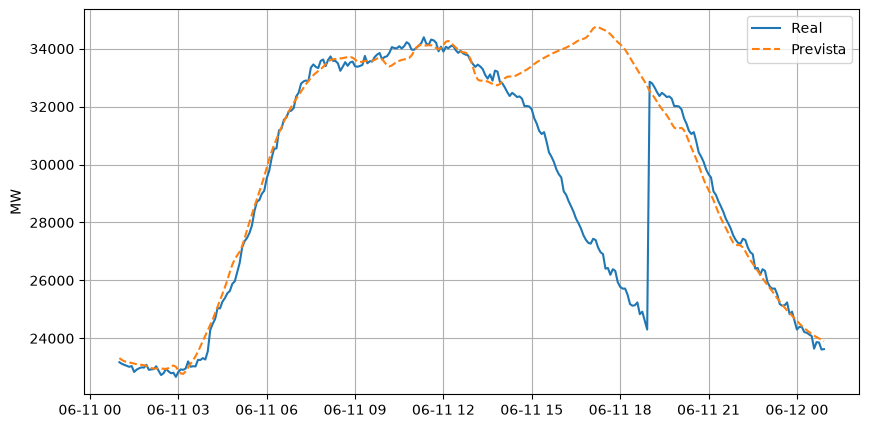

In [24]:
# Crear el gráfico
plt.figure(figsize=(10, 5))
plt.plot(
    df_demanda_dia["datetime"],
    df_demanda_dia["Demanda_Real_MW"],
    label="Real",
)
plt.plot(
    df_demanda_dia["datetime"],
    df_demanda_dia["Demanda_Prevista_MW"],
    label="Prevista",
    linestyle="--",
)

# Detalles mínimos
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
INICIO = "2026-06-11T12:00:00"
FIN = "2026-06-11T20:00:00"

HEADERS = {
    'x-api-key': TOKEN_ESIOS,
    'Accept': 'application/json; application/vnd.esios-api-v2+json',
    'Content-Type': 'application/json'
}

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}
url = f"https://api.esios.ree.es/indicators/1293"
response = requests.get(url, headers=HEADERS, params=PARAMS)
response.raise_for_status()

# Extraemos la lista de valores del JSON
datos_json = response.json()['indicator']['values']

# Convertimos a DataFrame
df_real_dia_11_junio = pd.DataFrame(datos_json)

In [26]:
df_real_dia_11_junio

,value,datetime,datetime_utc,tz_time,geo_id,geo_name
0,33713.0,2026-06-11T12:00:00.000+02:00,2026-06-11T10:00:00Z,2026-06-11T10:00:00.000Z,8741,Península
1,33737.0,2026-06-11T12:05:00.000+02:00,2026-06-11T10:05:00Z,2026-06-11T10:05:00.000Z,8741,Península
2,33860.0,2026-06-11T12:10:00.000+02:00,2026-06-11T10:10:00Z,2026-06-11T10:10:00.000Z,8741,Península
3,34056.0,2026-06-11T12:15:00.000+02:00,2026-06-11T10:15:00Z,2026-06-11T10:15:00.000Z,8741,Península
4,34022.0,2026-06-11T12:20:00.000+02:00,2026-06-11T10:20:00Z,2026-06-11T10:20:00.000Z,8741,Península
...,...,...,...,...,...,...
92,26193.0,2026-06-11T19:40:00.000+02:00,2026-06-11T17:40:00Z,2026-06-11T17:40:00.000Z,8741,Península
93,26387.0,2026-06-11T19:45:00.000+02:00,2026-06-11T17:45:00Z,2026-06-11T17:45:00.000Z,8741,Península
94,26327.0,2026-06-11T19:50:00.000+02:00,2026-06-11T17:50:00Z,2026-06-11T17:50:00.000Z,8741,Península
95,25939.0,2026-06-11T19:55:00.000+02:00,2026-06-11T17:55:00Z,2026-06-11T17:55:00.000Z,8741,Península


In [27]:
df_real_dia_11_junio["geo_name"].unique()

<ArrowStringArray>
['Península']
Length: 1, dtype: str

In [28]:
df_real_dia_11_junio["geo_id"].unique()

array([8741])

In [29]:
df_real_dia_11_junio["datetime"].duplicated().sum()

np.int64(0)

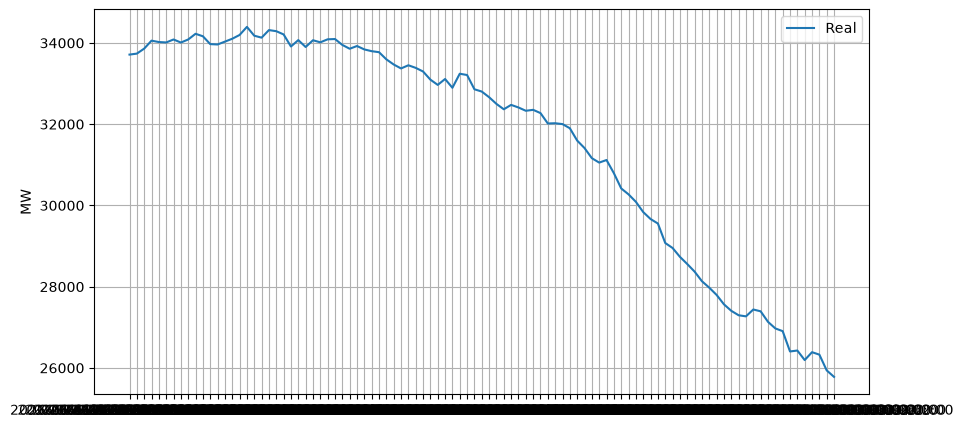

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(
    df_real_dia_11_junio["datetime"],
    df_real_dia_11_junio["value"],
    label="Real",
)

# Detalles mínimos
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Generación total o suma de tecnologías para 2026-06-11 12:00-20:00 UTC
# Si generación se mantiene estable ~34 GW mientras "demanda real" cae a 25 GW,
# la demanda es la que está rota, no el sistema

#Comprobado en REE, es un bug de la API

 Filtro de plausibilidad delta_5min sobre el crudo de 1293, antes del resample horario. Micro-bloque de hoy:

df_raw["delta_5min"] = df_raw["value"].diff() sobre la serie a 5 min
Mirar la distribución (describe(), percentiles altos) y fijar el umbral con el dato delante — candidato ya anotado: percentil 99.9
Aplicarlo y marcar filas sospechosas

In [32]:
INICIO = "2026-05-28T00:00:00"
FIN = "2026-06-28T23:59:59"

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}

try:
    df_raw_real = traer_dataframe_indicador(1293)
    
    # Mostramos los primeros datos en el Notebook
    display(df_raw_real.head())

except requests.exceptions.HTTPError as e:
    print(f"Error de la API (403/404): {e}")
except KeyError as e:
    print(f"Error en la estructura de columnas del JSON: {e}")

,datetime,indicador_1293
0,2026-05-27 22:00:00+00:00,26681.0
1,2026-05-27 22:05:00+00:00,26818.0
2,2026-05-27 22:10:00+00:00,27097.0
3,2026-05-27 22:15:00+00:00,26978.0
4,2026-05-27 22:20:00+00:00,26784.0


In [33]:
df_raw_real["delta_5min"] = df_raw_real["indicador_1293"].diff()

In [34]:
df_raw_real.head()

,datetime,indicador_1293,delta_5min
0,2026-05-27 22:00:00+00:00,26681.0,NaN
1,2026-05-27 22:05:00+00:00,26818.0,137.0
2,2026-05-27 22:10:00+00:00,27097.0,279.0
3,2026-05-27 22:15:00+00:00,26978.0,-119.0
4,2026-05-27 22:20:00+00:00,26784.0,-194.0


In [35]:
df_raw_real["delta_5min"].describe()

count    9215.000000
mean        0.155182
std       222.357724
min      -767.000000
25%      -134.000000
50%        -8.000000
75%       126.000000
max      8556.000000
Name: delta_5min, dtype: float64

In [36]:
df_raw_real["delta_5min"].quantile([0.001, 0.999])

0.001   -617.502
0.999    763.292
Name: delta_5min, dtype: float64

In [37]:
df_raw_real["delta_5min"].nlargest(15)

4284    8556.0
3580    1420.0
2123    1028.0
373      931.0
3579     915.0
3241     887.0
7561     862.0
361      806.0
5833     783.0
965      768.0
2377     746.0
5557     740.0
4105     736.0
2689     726.0
3253     726.0
Name: delta_5min, dtype: float64

In [38]:
df_raw_real["delta_5min"].nsmallest(15)

7210   -767.0
9212   -707.0
6003   -666.0
5741   -641.0
6093   -640.0
8061   -629.0
3054   -623.0
7098   -623.0
852    -620.0
8808   -619.0
8323   -612.0
5449   -609.0
828    -604.0
3639   -600.0
9207   -599.0
Name: delta_5min, dtype: float64

In [39]:
df_raw_real.iloc[3580]

datetime          2026-06-09 08:20:00+00:00
indicador_1293                      34215.0
delta_5min                           1420.0
Name: 3580, dtype: object

In [40]:
df_raw_real.iloc[2123]

datetime          2026-06-04 06:55:00+00:00
indicador_1293                      33113.0
delta_5min                           1028.0
Name: 2123, dtype: object

Umbral confirmado: UMBRAL_DELTA = 2000, simétrico. Justificación cerrada: por encima del máximo salto físico verificado (1.420 MW, rampa de mañana laborable), un orden de magnitud por debajo del artefacto (8.556).

In [41]:
UMBRAL_DELTA = 2000
df_raw_real["salto_implausible"] = df_raw_real["delta_5min"].abs() > UMBRAL_DELTA
df_raw_real["salto_implausible"].sum()

np.int64(1)

Limpiamos los datos usando la demanda real y ese límite que acabamos de trazar
Entrenamos el modelo
En producción:
1. predecimos demanda del día n
2. el día n+1 el modelo mira al día n. Para comprobar los datos de la API, a falta de más indicadores, vuelve a casar demanda prevista por REE y demanda real. Si no hay fallos, calculamos el error con demanda real y demanda prevista por el modelo. 

In [42]:
def traer_dataframe_indicador(indicador_id, PARAMS, HEADERS, nombre_col):
    """Hace la petición a e·sios con x-api-key v2 y devuelve un DataFrame limpio.
    
    Deja subir las excepciones (HTTPError, KeyError, etc.) para que el orquestador
    las gestione y registre adecuadamente.
    """
    url = f"https://api.esios.ree.es/indicators/{indicador_id}"
    response = requests.get(url, headers=HEADERS, params=PARAMS)
    response.raise_for_status()
    
    # Extraemos la lista de valores del JSON
    datos_json = response.json()['indicator']['values']
    
    # Convertimos a DataFrame
    df = pd.DataFrame(datos_json)
    
    # Verificación de la columna de tiempo por si la API la nombra 'datetime_utc'
    columna_fecha = 'datetime' if 'datetime' in df.columns else 'datetime_utc'
    
    # Normalización del DataFrame para el merge con el nombre definitivo
    df[columna_fecha] = pd.to_datetime(df[columna_fecha], utc=True)
    df = df[[columna_fecha, 'value']].rename(
        columns={columna_fecha: 'datetime', 'value': nombre_col}
    )
    
    return df

def incidencia_api(indicador, PARAMS, HEADERS, nombre_col):
    """Intenta obtener el DataFrame. 
    
    Devuelve una tupla: (DataFrame o None, Diccionario de incidencia o None)
    """
    try:
        df = traer_dataframe_indicador(indicador, PARAMS, HEADERS, nombre_col)
        return df, None  # Todo bien: devolvemos el dataframe y ninguna incidencia
        
    except requests.exceptions.HTTPError as e:
        status_code = e.response.status_code if e.response is not None else "Desconocido"
        incidencia = {
            "indicador": indicador,
            "tipo_error": f"HTTP_{status_code}",
            "mensaje": str(e)
        }
        return None, incidencia
        
    except KeyError as e:
        incidencia = {
            "indicador": indicador,
            "tipo_error": "Estructura_JSON",
            "mensaje": f"Falta la columna o clave: {str(e)}"
        }
        return None, incidencia
        
    except Exception as e:
        incidencia = {
            "indicador": indicador,
            "tipo_error": type(e).__name__,
            "mensaje": str(e)
        }
        return None, incidencia

In [43]:
HEADERS = {
    'x-api-key': TOKEN_ESIOS,
    'Accept': 'application/json; application/vnd.esios-api-v2+json',
    'Content-Type': 'application/json'
}

INICIO = "2024-01-01T00:00:00"
FIN = "2024-01-31T23:59:59"

PARAMS = {
    'start_date': INICIO,
    'end_date': FIN
}
# 1293: Demanda Real Peninsular
# 544: Previsión de la Demanda de REE
indicador = 1293
data_enero_2024 = traer_dataframe_indicador(indicador, PARAMS, HEADERS, "demanda_real")
data_enero_2024

,datetime,demanda_real
0,2023-12-31 23:00:00+00:00,22021.0
1,2023-12-31 23:05:00+00:00,22062.0
2,2023-12-31 23:10:00+00:00,22101.0
3,2023-12-31 23:15:00+00:00,21991.0
4,2023-12-31 23:20:00+00:00,21893.0
...,...,...
8923,2024-01-31 22:35:00+00:00,26758.0
8924,2024-01-31 22:40:00+00:00,26485.0
8925,2024-01-31 22:45:00+00:00,26239.0
8926,2024-01-31 22:50:00+00:00,26025.0


In [44]:
incidencia_api(indicador, PARAMS, HEADERS, "demanda_real")

(                      datetime  demanda_real
 0    2023-12-31 23:00:00+00:00       22021.0
 1    2023-12-31 23:05:00+00:00       22062.0
 2    2023-12-31 23:10:00+00:00       22101.0
 3    2023-12-31 23:15:00+00:00       21991.0
 4    2023-12-31 23:20:00+00:00       21893.0
 ...                        ...           ...
 8923 2024-01-31 22:35:00+00:00       26758.0
 8924 2024-01-31 22:40:00+00:00       26485.0
 8925 2024-01-31 22:45:00+00:00       26239.0
 8926 2024-01-31 22:50:00+00:00       26025.0
 8927 2024-01-31 22:55:00+00:00       25909.0
 
 [8928 rows x 2 columns],
 None)

In [45]:
def descarga_mes(indicador_id, anio, mes, nombre_col, HEADERS):
    """Descarga un mes completo en UTC, valida filas a 5 min y guarda en Parquet si es OK."""
    ruta_carpeta = "raw"
    ruta_fichero = f"{ruta_carpeta}/{indicador_id}_{anio}-{mes:02d}.parquet"
    
    # 1. Ajuste de escala: Volvemos a los 5 minutos nativos (288 intervalos por día)
    dias_del_mes = calendar.monthrange(anio, mes)[1]
    filas_esperadas = dias_del_mes * 288
    
    resultado = {
        "indicador": indicador_id,
        "mes": f"{anio}-{mes:02d}",
        "filas_obtenidas": 0,
        "filas_esperadas": filas_esperadas,
        "estado": "PENDIENTE",
        "detalle": ""
    }
    
    # 2. Idempotencia defensiva (Compara también longitud para evitar parquets cojos)
    if os.path.exists(ruta_fichero):
        try:
            df_existente = pd.read_parquet(ruta_fichero)
            if len(df_existente) == filas_esperadas:
                resultado["filas_obtenidas"] = len(df_existente)
                resultado["estado"] = "EXISTENTE (SKIPPED)"
                return resultado
            else:
                resultado["estado"] = "EXISTENTE_CORRUPTO"
                resultado["detalle"] = f"El archivo local tiene {len(df_existente)} filas, se esperaban {filas_esperadas}. Se reintenta descarga."
        except Exception as e:
            resultado["estado"] = "ERROR_LECTURA_LOCAL"
            resultado["detalle"] = f"Fichero ilegible: {e}. Se intentará descargar de nuevo."
            # No retornamos aquí para permitir que intente machacarlo bajándolo de la API

    # 3. Construcción de PARAMS nativos (sin truncados horarios)
    ultimo_dia = calendar.monthrange(anio, mes)[1]
    PARAMS = {
        'start_date': f"{anio}-{mes:02d}-01T00:00:00Z",
        'end_date': f"{anio}-{mes:02d}-{ultimo_dia:02d}T23:59:59Z"
    }
    
    # El try externo ahora se enfoca en fallos del sistema/disco, el de la API va controlado
    try:
        os.makedirs(ruta_carpeta, exist_ok=True)
        
        # CORREGIDO: Llamamos a incidencia_api para recibir la tupla de control correctamente
        df, incidencia = incidencia_api(indicador_id, PARAMS, HEADERS, nombre_col)
        
        if incidencia:
            resultado["estado"] = incidencia["tipo_error"]
            resultado["detalle"] = incidencia["mensaje"]
            return resultado
            
        if df is None or df.empty:
            resultado["estado"] = "VACIO"
            return resultado
            
        resultado["filas_obtenidas"] = len(df)
        
        # 4. CORREGIDO: Validación estricta ANTES de persistir en disco
        if resultado["filas_obtenidas"] == resultado["filas_esperadas"]:
            df.to_parquet(ruta_fichero, index=False)
            resultado["estado"] = "OK"
        else:
            resultado["estado"] = "DESCUADRE_CONTEO"
            resultado["detalle"] = f"Esperadas {resultado['filas_esperadas']}, obtenidas {resultado['filas_obtenidas']}. Archivo NO guardado."
            
    except Exception as e:
        resultado["estado"] = "ERROR_SISTEMA_DISCO"
        resultado["detalle"] = str(e)
        
    return resultado

In [48]:
pruebas = [
        {"id": 1293, "col": "demanda_real"},
        {"id": 544, "col": "demanda_prevista"}
    ]
    
print("=== 1. LANZANDO EJECUCIÓN CONTROLADA ===")
for p in pruebas:
    reporte = descarga_mes(p["id"], 2024, 1, p["col"], HEADERS)
    print(f"Indicador {reporte['indicador']}: Estado -> {reporte['estado']} | Filas: {reporte['filas_obtenidas']}/{reporte['filas_esperadas']}")
    if reporte["detalle"]:
        print(f"   ⚠️ Detalle: {reporte['detalle']}")

print("\n=== 2. VERIFICACIÓN Y LECTURA ESTADÍSTICA EN DISCO ===")
for p in pruebas:
    ruta = f"raw/{p['id']}_2024-01.parquet"
    if os.path.exists(ruta):
        df_disco = pd.read_parquet(ruta)
        print(f"Fichero: {ruta} -> ¡OK!")
        print(f"   Estructura leída de Parquet: {df_disco.shape}")
        print(f"   Primer registro del índice: {df_disco['datetime'].iloc[0]}")
        print(f"   Último registro del índice:  {df_disco['datetime'].iloc[-1]}")
        # Testeo rápido de deltas para confirmar los 5 minutos nativos
        deltas = df_disco['datetime'].diff().value_counts()
        print(f"   Frecuencias de deltas detectadas:\n{deltas}\n")
    else:
        print(f"❌ Archivo esperado no encontrado en disco: {ruta}")

=== 1. LANZANDO EJECUCIÓN CONTROLADA ===
Indicador 1293: Estado -> EXISTENTE (SKIPPED) | Filas: 8928/8928
Indicador 544: Estado -> EXISTENTE (SKIPPED) | Filas: 8928/8928

=== 2. VERIFICACIÓN Y LECTURA ESTADÍSTICA EN DISCO ===
Fichero: raw/1293_2024-01.parquet -> ¡OK!
   Estructura leída de Parquet: (8928, 2)
   Primer registro del índice: 2024-01-01 00:00:00+00:00
   Último registro del índice:  2024-01-31 23:55:00+00:00
   Frecuencias de deltas detectadas:
datetime
0 days 00:05:00    8927
Name: count, dtype: int64

Fichero: raw/544_2024-01.parquet -> ¡OK!
   Estructura leída de Parquet: (8928, 2)
   Primer registro del índice: 2024-01-01 00:00:00+00:00
   Último registro del índice:  2024-01-31 23:55:00+00:00
   Frecuencias de deltas detectadas:
datetime
0 days 00:05:00    8927
Name: count, dtype: int64



In [49]:
#concatenación y umbrales

In [50]:
import sys
from pathlib import Path

raiz = Path.cwd().parent

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))


In [53]:
import glob
# 1. Localizar todos los archivos Parquet del indicador 1293 en la carpeta 'raw'
ruta_carpeta = "../notebooks/raw"
patron_archivos = os.path.join(ruta_carpeta, "1293_*.parquet")
archivos = sorted(glob.glob(patron_archivos))

print(f"Se han encontrado {len(archivos)} archivos Parquet para concatenar.")

# 2. Leer y concatenar todos los archivos en un único DataFrame
df_historico = pd.concat([pd.read_parquet(f) for f in archivos], ignore_index=True)
print(df_historico.head())

# 3. Convertir 'datetime' a tipo Timestamp (si no lo estuviera ya) y ordenar cronológicamente
df_historico['datetime_utc'] = pd.to_datetime(df_historico['datetime_utc'])
df_historico = df_historico.sort_values(by='datetime_utc').reset_index(drop=True)

# 4. Calcular el delta (diferencia consecutiva de demanda cada 5 minutos)
df_historico['delta'] = df_historico['demanda_real'].diff()

# 5. Obtener el valor absoluto de los deltas para el análisis de extremos
deltas_absolutos = df_historico['delta'].abs()

# 6. Generar el reporte estadístico completo
stats_basicas = deltas_absolutos.describe()

# Calcular percentiles específicos y el máximo absoluto
percentiles_extra = pd.Series({
    'p99.0': deltas_absolutos.quantile(0.99),
    'p99.9': deltas_absolutos.quantile(0.999),
    'max_absoluto': deltas_absolutos.max()
})

# Combinar las estadísticas en un único DataFrame limpio
reporte_volatilidad = pd.concat([stats_basicas, percentiles_extra]).to_frame(name='Valores abs(delta)')

print("\n=== Análisis de Extremos en Deltas de Demanda (5 min) ===")
print(reporte_volatilidad)

Se han encontrado 41 archivos Parquet para concatenar.
               datetime_utc  demanda_real
0 2023-01-01 00:00:00+00:00       19749.0
1 2023-01-01 00:05:00+00:00       19623.0
2 2023-01-01 00:10:00+00:00       19590.0
3 2023-01-01 00:15:00+00:00       19509.0
4 2023-01-01 00:20:00+00:00       19418.0

=== Análisis de Extremos en Deltas de Demanda (5 min) ===
              Valores abs(delta)
count              359135.000000
mean                  145.726671
std                   126.448351
min                     0.000000
25%                    55.000000
50%                   118.000000
75%                   207.000000
max                 25184.000000
p99.0                 526.000000
p99.9                 820.866000
max_absoluto        25184.000000
